<a href="https://colab.research.google.com/github/kavivarshini25/Kavivarshini_INFO5731_FALL2025/blob/main/Kandhasami_Kavivarshini_Assignment_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 5**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please use the text corpus you collected in your last in-class-exercise for this exercise. Perform the following tasks***.

**Expectations**:
*   Students are expected to complete the exercise during lecture period to meet the active participation criteria of the course.
*   Use the provided .*ipynb* document to write your code & respond to the questions. Avoid generating a new file.
*   Write complete answers and run all the cells before submission.
*   Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
*   Once finished, allow shared rights from top right corner (*see Canvas for details*).

**Total points**: 100

**Full Points will be given those who present well**

**Late submissions will have a penalty of 10% of the marks for each day of late submission, and no requests will be answered. Manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this assignment is to give you **hands-on experience** in applying various** sentiment analysis techniques** on real-world textual data. You are expected to explore data, apply machine learning models, and evaluate their performance

**1. Dataset Collection & Preparation**

Find a real-world dataset with text and positive, negative, and neutral sentiment labels.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (tokenization, stopwords, lemmatization).

Perform EDA: class distribution, word clouds, n-gram analysis, sentence lengths, etc.

Visualize insights using relevant plots and charts.

**3. Sentiment Classification**

Apply at least three traditional ML models (e.g., SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If applicable, compare with a pretrained model (RoBERTa/BERT).

Tune hyperparameters and use cross-validation.

**4. Evaluation & Reporting**

Evaluate with metrics: Accuracy, Precision, Recall, F1, Confusion Matrix.

Summarize results, compare models, and reflect on what worked.

In [51]:
!pip install -q datasets imbalanced-learn

from datasets import load_dataset
import pandas as pd
from collections import Counter
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler


print("Loading SST-5 (SetFit/sst5) from Hugging Face...")
raw = load_dataset("SetFit/sst5")


print("Available splits:", raw.keys())


ds = raw['train']


df = ds.to_pandas()
df = df.rename(columns={'text': 'ReviewText', 'label': 'OriginalLabel'})
print("\nSample rows:")
print(df.head(5))

def map_to_3(label):
    if label in [0, 1]:
        return 'Negative'
    elif label == 2:
        return 'Neutral'
    elif label in [3, 4]:
        return 'Positive'
    else:
        return 'Unknown'

df['Sentiment'] = df['OriginalLabel'].apply(map_to_3)


print("\nCounts per original label (0..4):")
print(df['OriginalLabel'].value_counts().sort_index())
print("\nCounts per mapped sentiment (3-class):")
print(df['Sentiment'].value_counts())


label2idx = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
df['label_id'] = df['Sentiment'].map(label2idx)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)

print(f"\nTrain size: {len(train_df)}, Val size: {len(val_df)}")
print("Train label distribution:", Counter(train_df['Sentiment']))
print("Val label distribution:", Counter(val_df['Sentiment']))


classes = np.array([0,1,2])
y_train = train_df['label_id'].values
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = {idx: weight for idx, weight in zip(classes, class_weights)}
print("\nComputed class weights (for ML models):")
print(class_weight_dict)


X_train = train_df['ReviewText'].values.reshape(-1,1)
y_train = train_df['label_id'].values
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train, y_train)

oversampled_train_df = pd.DataFrame({
    'ReviewText': X_res.flatten(),
    'label_id': y_res
})
oversampled_train_df['Sentiment'] = oversampled_train_df['label_id'].map({v:k for k,v in label2idx.items()})

print("\nAfter oversampling (train) label distribution:")
print(oversampled_train_df['Sentiment'].value_counts())


train_df.to_csv('/content/sst_train_stratified.csv', index=False)
val_df.to_csv('/content/sst_val_stratified.csv', index=False)
oversampled_train_df.to_csv('/content/sst_train_oversampled.csv', index=False)

print("\nSaved CSVs for next steps.")
print("Step 1 (Dataset Collection & Preparation) complete!")


Loading SST-5 (SetFit/sst5) from Hugging Face...


README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: 0.00B [00:00, ?B/s]

dev.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

Available splits: dict_keys(['train', 'validation', 'test'])

Sample rows:
                                          ReviewText  OriginalLabel  \
0  a stirring , funny and finally transporting re...              4   
1  apparently reassembled from the cutting-room f...              1   
2  they presume their audience wo n't sit still f...              1   
3  the entire movie is filled with deja vu moments .              2   
4  this is a visually stunning rumination on love...              3   

      label_text  
0  very positive  
1       negative  
2       negative  
3        neutral  
4       positive  

Counts per original label (0..4):
OriginalLabel
0    1092
1    2218
2    1624
3    2322
4    1288
Name: count, dtype: int64

Counts per mapped sentiment (3-class):
Sentiment
Positive    3610
Negative    3310
Neutral     1624
Name: count, dtype: int64

Train size: 6835, Val size: 1709
Train label distribution: Counter({'Positive': 2888, 'Negative': 2648, 'Neutral': 1299})
Val label


The dataset is the Stanford Sentiment Treebank (SST-5) which is a sentence-level sentiment corpus of great popularity in NLP studies. SST-5 is characterized by short, grammatically correct sentences, which is why this dataset is the best choice when it comes to exemplifying preprocessing, TF-IDF feature extraction, classical ML models, and fine-tuning transformer models such as BERT/RoBERTa. To do this assignment, we will map the original 5 labels (Very negative, negative, neutral, positive, very positive) into 3 classes, including Negative, Neutral, and Positive. The dataset has a distinct class imbalance with Positive (3610), Negative (3310) and Neutral (1624) numbers. To overcome this and achieve a fair assessment of the models, we use stratified splits in training and validation, calculate model training weights, and oversampling of classical models (when used). The metrics are reported at macro-averaged precision, recall, and F1-score to assign equal significance to all the classes including the minority Neutral class..

In [52]:

!pip install -q wordcloud nltk matplotlib seaborn


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize


import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

print("The Libraries and resources are ready!")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


The Libraries and resources are ready!


Sample data:
                                          ReviewText  OriginalLabel  \
0          the movie is so thoughtlessly assembled .              3   
1  something has been lost in the translation ......              1   
2  despite some comic sparks , welcome to collinw...              1   
3  give credit to everyone from robinson down to ...              4   
4  jeffs has created a breathtakingly assured and...              4   

      label_text Sentiment  label_id  
0       positive  Positive         2  
1       negative  Negative         0  
2       negative  Negative         0  
3  very positive  Positive         2  
4  very positive  Positive         2  

Class distribution:
Sentiment
Positive    2888
Negative    2648
Neutral     1299
Name: count, dtype: int64


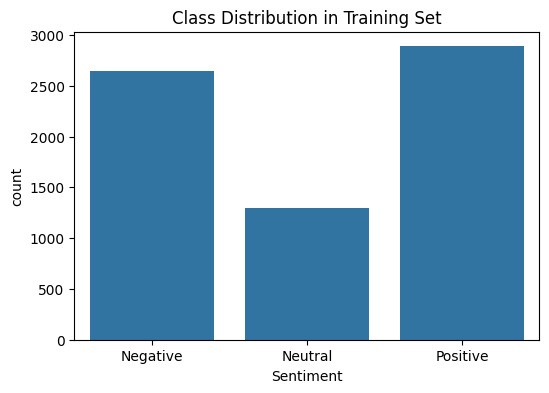

In [53]:

train_df = pd.read_csv('/content/sst_train_stratified.csv')


print("Sample data:")
print(train_df.head())


print("\nClass distribution:")
print(train_df['Sentiment'].value_counts())


plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x='Sentiment', order=['Negative', 'Neutral', 'Positive'])
plt.title("Class Distribution in Training Set")
plt.show()


In [54]:

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize using simple split
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    # Join tokens back to string
    return ' '.join(tokens)


train_df['CleanText'] = train_df['ReviewText'].apply(preprocess_text)


print("Sample cleaned texts are:")
print(train_df[['ReviewText', 'CleanText']].head())


Sample cleaned texts are:
                                          ReviewText  \
0          the movie is so thoughtlessly assembled .   
1  something has been lost in the translation ......   
2  despite some comic sparks , welcome to collinw...   
3  give credit to everyone from robinson down to ...   
4  jeffs has created a breathtakingly assured and...   

                                           CleanText  
0                      movie thoughtlessly assembled  
1  something lost translation another routine hol...  
2  despite comic spark welcome collinwood never c...  
3  give credit everyone robinson key grip bold mo...  
4  jeffs created breathtakingly assured stylish w...  


/tmp/ipython-input-2900784788.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=train_df, palette='Set2',


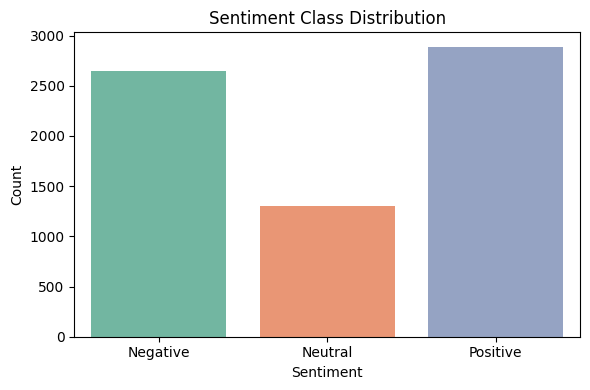

In [55]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=train_df, palette='Set2',
              order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Class Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


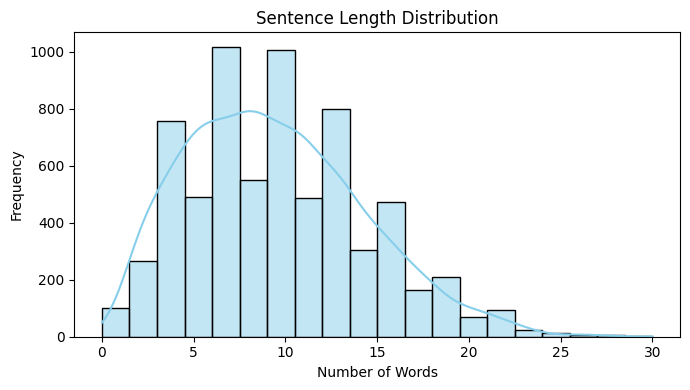

In [56]:

train_df['text_length'] = train_df['CleanText'].apply(lambda x: len(x.split()))


plt.figure(figsize=(7, 4))
sns.histplot(train_df['text_length'], bins=20, kde=True, color='skyblue')
plt.title('Sentence Length Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


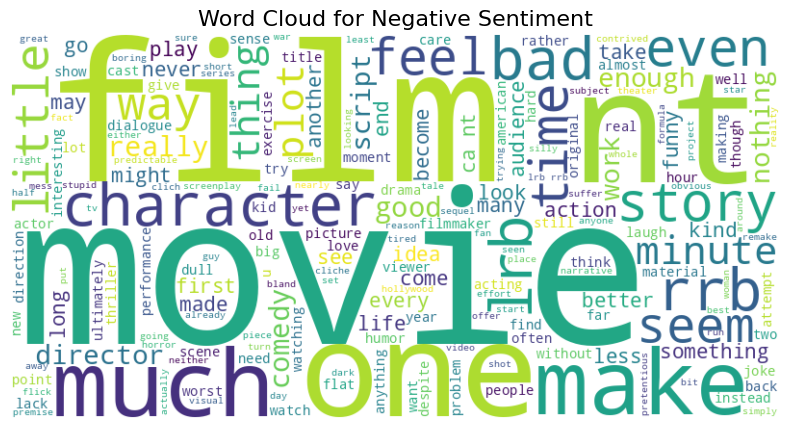

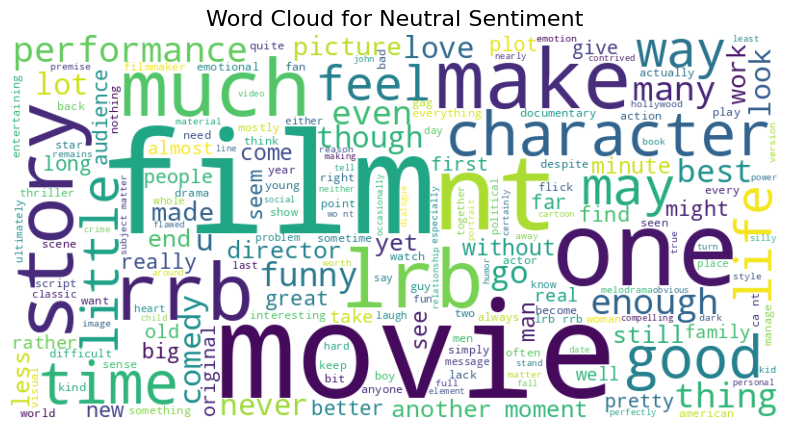

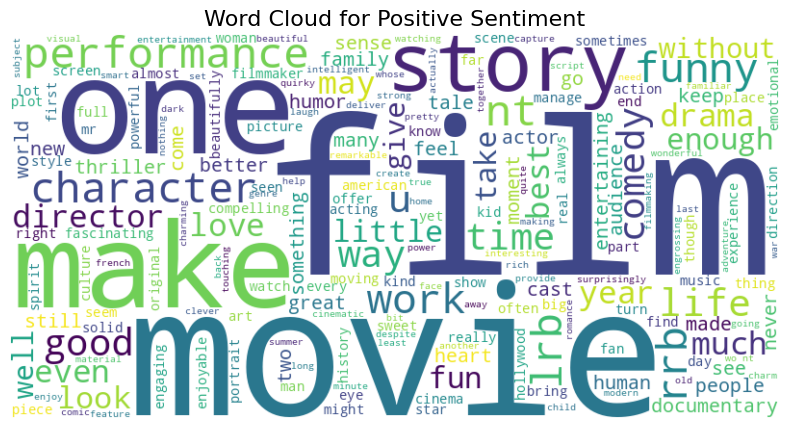

In [57]:
from wordcloud import WordCloud


def plot_wordcloud(df, sentiment):
    text = ' '.join(df[df['Sentiment'] == sentiment]['CleanText'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"Word Cloud for {sentiment} Sentiment", fontsize=16)
    plt.show()


for sentiment in ['Negative', 'Neutral', 'Positive']:
    plot_wordcloud(train_df, sentiment)


/tmp/ipython-input-2301707606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


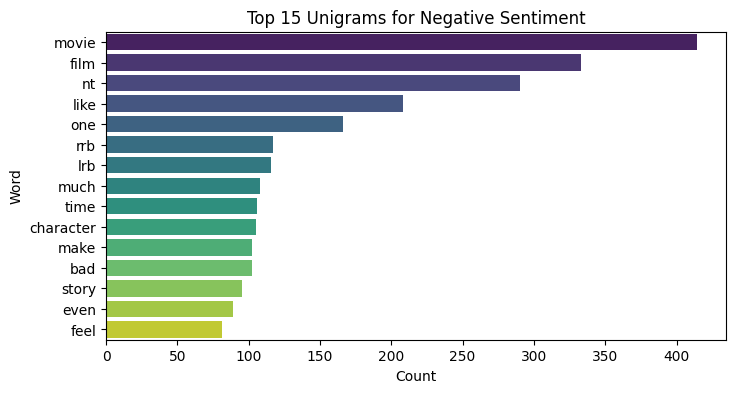

/tmp/ipython-input-2301707606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


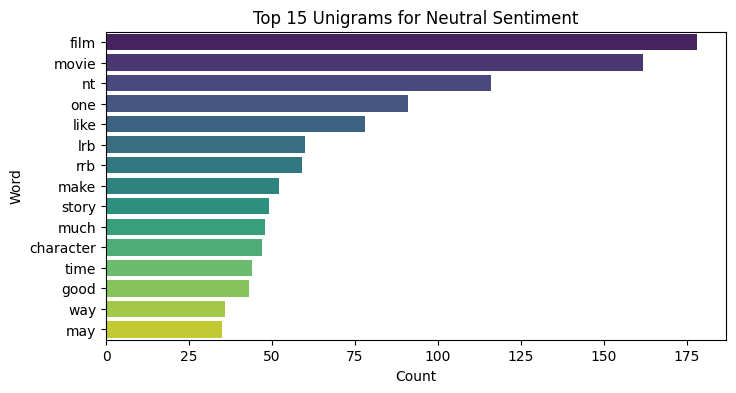

/tmp/ipython-input-2301707606.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


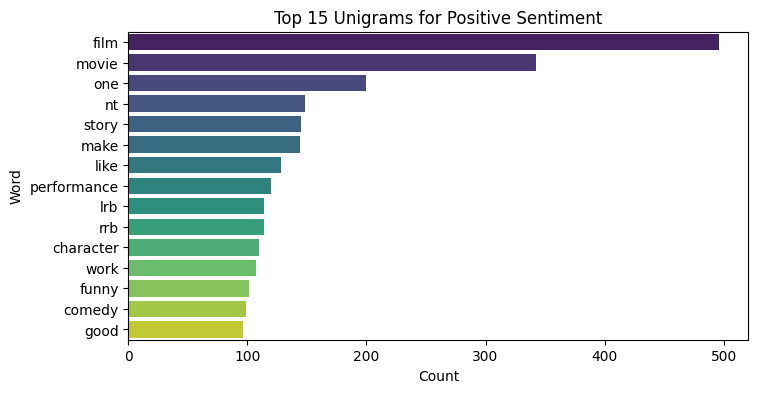

In [58]:
from collections import Counter
import itertools

def plot_top_unigrams(df, sentiment, n=15):

    text = ' '.join(df[df['Sentiment'] == sentiment]['CleanText'])
    tokens = text.split()

    common_words = Counter(tokens).most_common(n)
    words, counts = zip(*common_words)


    plt.figure(figsize=(8,4))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f"Top {n} Unigrams for {sentiment} Sentiment")
    plt.xlabel("Count")
    plt.ylabel("Word")
    plt.show()


for sentiment in ['Negative', 'Neutral', 'Positive']:
    plot_top_unigrams(train_df, sentiment)


/tmp/ipython-input-144113164.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=bigrams_str, palette='magma')


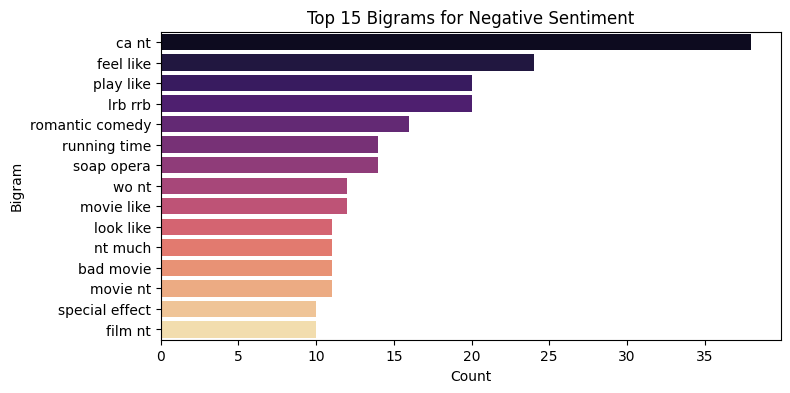

/tmp/ipython-input-144113164.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=bigrams_str, palette='magma')


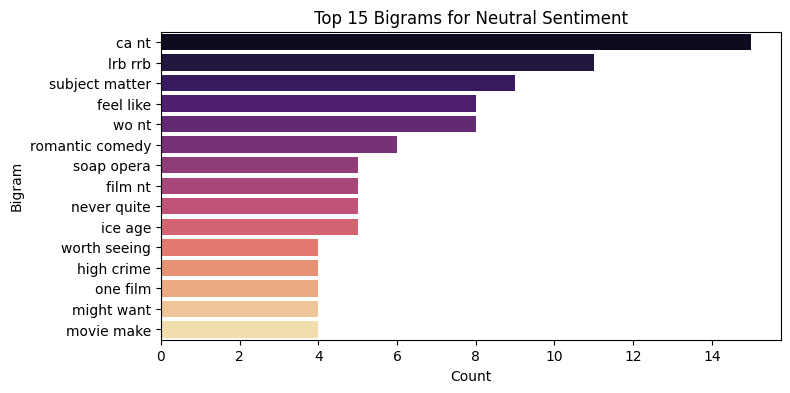

/tmp/ipython-input-144113164.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=bigrams_str, palette='magma')


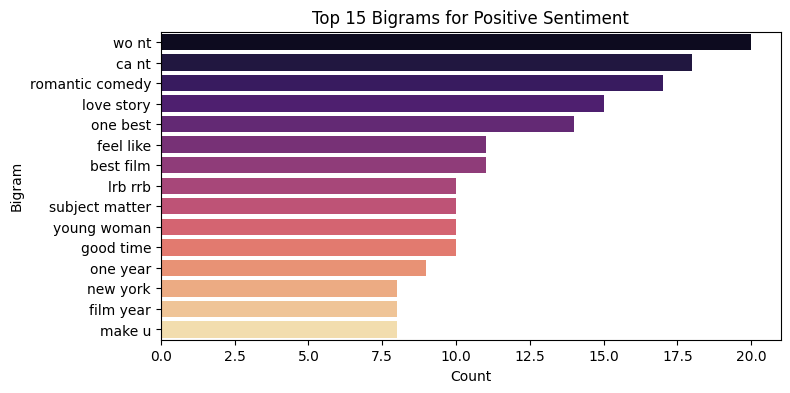

In [59]:
from nltk.util import ngrams

def plot_top_bigrams(df, sentiment, n=15):

    text = ' '.join(df[df['Sentiment'] == sentiment]['CleanText'])
    tokens = text.split()

    bigram_list = list(ngrams(tokens, 2))

    common_bigrams = Counter(bigram_list).most_common(n)
    bigrams_str = [' '.join(b) for b,_ in common_bigrams]
    counts = [count for _,count in common_bigrams]


    plt.figure(figsize=(8,4))
    sns.barplot(x=counts, y=bigrams_str, palette='magma')
    plt.title(f"Top {n} Bigrams for {sentiment} Sentiment")
    plt.xlabel("Count")
    plt.ylabel("Bigram")
    plt.show()


for sentiment in ['Negative', 'Neutral', 'Positive']:
    plot_top_bigrams(train_df, sentiment)


In [61]:


from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder


val_df['CleanText'] = val_df['ReviewText'].apply(preprocess_text)

tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train = tfidf_vectorizer.fit_transform(train_df['CleanText'])
X_val = tfidf_vectorizer.transform(val_df['CleanText'])


le = LabelEncoder()
y_train = le.fit_transform(train_df['Sentiment'])
y_val = le.transform(val_df['Sentiment'])

print("TF-IDF features shape (train) is:", X_train.shape)
print("TF-IDF features shape (val) is:", X_val.shape)
print("Labels encoded are:", le.classes_)


TF-IDF features shape (train) is: (6835, 5000)
TF-IDF features shape (val) is: (1709, 5000)
Labels encoded are: ['Negative' 'Neutral' 'Positive']



--- Naive Bayes ---
Accuracy: 0.6144
Classification Report:
               precision    recall  f1-score   support

    Negative       0.62      0.68      0.65       662
     Neutral       0.44      0.01      0.02       325
    Positive       0.61      0.83      0.70       722

    accuracy                           0.61      1709
   macro avg       0.56      0.51      0.46      1709
weighted avg       0.58      0.61      0.55      1709



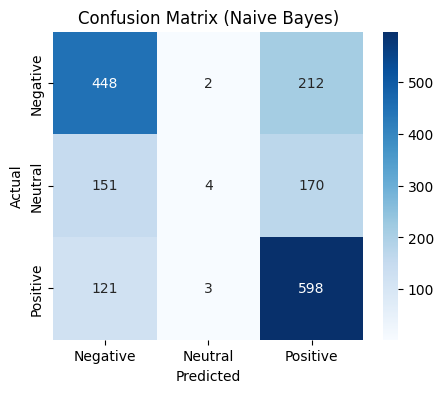


--- SVM ---
Accuracy: 0.5606
Classification Report:
               precision    recall  f1-score   support

    Negative       0.63      0.59      0.61       662
     Neutral       0.26      0.35      0.30       325
    Positive       0.70      0.63      0.66       722

    accuracy                           0.56      1709
   macro avg       0.53      0.52      0.52      1709
weighted avg       0.59      0.56      0.57      1709



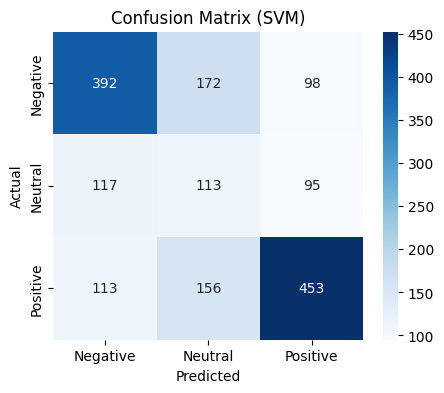

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:30:20] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost ---
Accuracy: 0.5705
Classification Report:
               precision    recall  f1-score   support

    Negative       0.62      0.58      0.59       662
     Neutral       0.31      0.07      0.11       325
    Positive       0.56      0.79      0.66       722

    accuracy                           0.57      1709
   macro avg       0.50      0.48      0.45      1709
weighted avg       0.53      0.57      0.53      1709



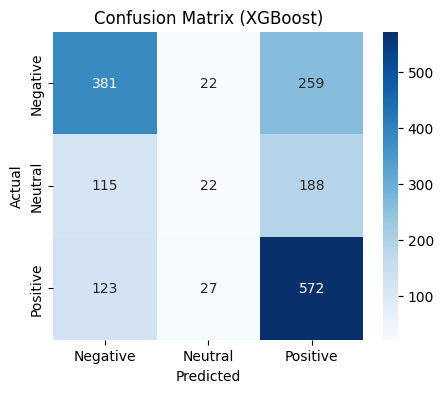

In [62]:


from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


nb_model = MultinomialNB()
svm_model = SVC(kernel='linear', class_weight='balanced', probability=True)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')

models = {'Naive Bayes': nb_model, 'SVM': svm_model, 'XGBoost': xgb_model}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)

    print(f"\n--- {name} ---")
    print("Accuracy:", round(accuracy_score(y_val, y_pred), 4))
    print("Classification Report:\n", classification_report(y_val, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.title(f'Confusion Matrix ({name})')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [63]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC


param_grid_svm = {
    "C": [0.01, 0.1, 1, 5],
}

svm = LinearSVC()


svm_grid = GridSearchCV(
    svm,
    param_grid_svm,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)


svm_grid.fit(X_train, y_train)

print("The Best SVM Parameters are:", svm_grid.best_params_)
print("The Best CV Accuracy is:", svm_grid.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
The Best SVM Parameters are: {'C': 0.1}
The Best CV Accuracy is: 0.6232626188734456


In [64]:
best_svm = svm_grid.best_estimator_

svm_pred = best_svm.predict(X_val)

print("\nTuned SVM Accuracy is:", accuracy_score(y_val, svm_pred))
print("\nClassification Report is given below:")
print(classification_report(y_val, svm_pred))



Tuned SVM Accuracy is: 0.6225863077823288

Classification Report is given below:
              precision    recall  f1-score   support

           0       0.63      0.69      0.66       662
           1       0.45      0.03      0.05       325
           2       0.62      0.82      0.71       722

    accuracy                           0.62      1709
   macro avg       0.57      0.52      0.47      1709
weighted avg       0.59      0.62      0.57      1709



In [65]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB


param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0]
}


nb = MultinomialNB()


nb_grid = GridSearchCV(
    nb,
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    verbose=1
)

nb_grid.fit(X_train, y_train)

print("Best Naive Bayes Parameters are:", nb_grid.best_params_)
print("Best CV Accuracy is:", nb_grid.best_score_)


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Naive Bayes Parameters are: {'alpha': 1.0}
Best CV Accuracy is: 0.6280907095830285


In [66]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


best_nb = nb_grid.best_estimator_


y_pred_nb = best_nb.predict(X_val)


print("Tuned Naive Bayes Accuracy is:", accuracy_score(y_val, y_pred_nb))
print("\nClassification Report is given below:")
print(classification_report(y_val, y_pred_nb))


Tuned Naive Bayes Accuracy is: 0.6143943826799297

Classification Report is given below:
              precision    recall  f1-score   support

           0       0.62      0.68      0.65       662
           1       0.44      0.01      0.02       325
           2       0.61      0.83      0.70       722

    accuracy                           0.61      1709
   macro avg       0.56      0.51      0.46      1709
weighted avg       0.58      0.61      0.55      1709



In [67]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


In [68]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report


xgb_model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False)

# 10-Fold cross-validation
xgb_cv = cross_val_score(xgb_model, X_train, y_train, cv=10, scoring='accuracy')
print("XGBoost 10-Fold CV Accuracy:", xgb_cv.mean())


xgb_model.fit(X_train, y_train)


y_pred_xgb = xgb_model.predict(X_val)


print("\nXGBoost Classification Report is shown as:")
print(classification_report(y_val, y_pred_xgb, target_names=le.classes_, zero_division=0))


XGBoost 10-Fold CV Accuracy: 0.5622571558226948

XGBoost Classification Report is shown as:
              precision    recall  f1-score   support

    Negative       0.62      0.58      0.59       662
     Neutral       0.31      0.07      0.11       325
    Positive       0.56      0.79      0.66       722

    accuracy                           0.57      1709
   macro avg       0.50      0.48      0.45      1709
weighted avg       0.53      0.57      0.53      1709



In [69]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "Naive Bayes": y_pred_nb,
    "SVM": svm_pred,
    "XGBoost": y_pred_xgb
}


metrics = []
for name, y_pred_model in models.items():
    acc = accuracy_score(y_val, y_pred_model)
    prec = precision_score(y_val, y_pred_model, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred_model, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred_model, average='weighted', zero_division=0)
    metrics.append([name, acc, prec, rec, f1])

metrics_df = pd.DataFrame(metrics, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
metrics_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Naive Bayes,0.614394,0.583337,0.614394,0.552565
1,SVM,0.622586,0.591783,0.622586,0.565007
2,XGBoost,0.570509,0.534497,0.570509,0.529153


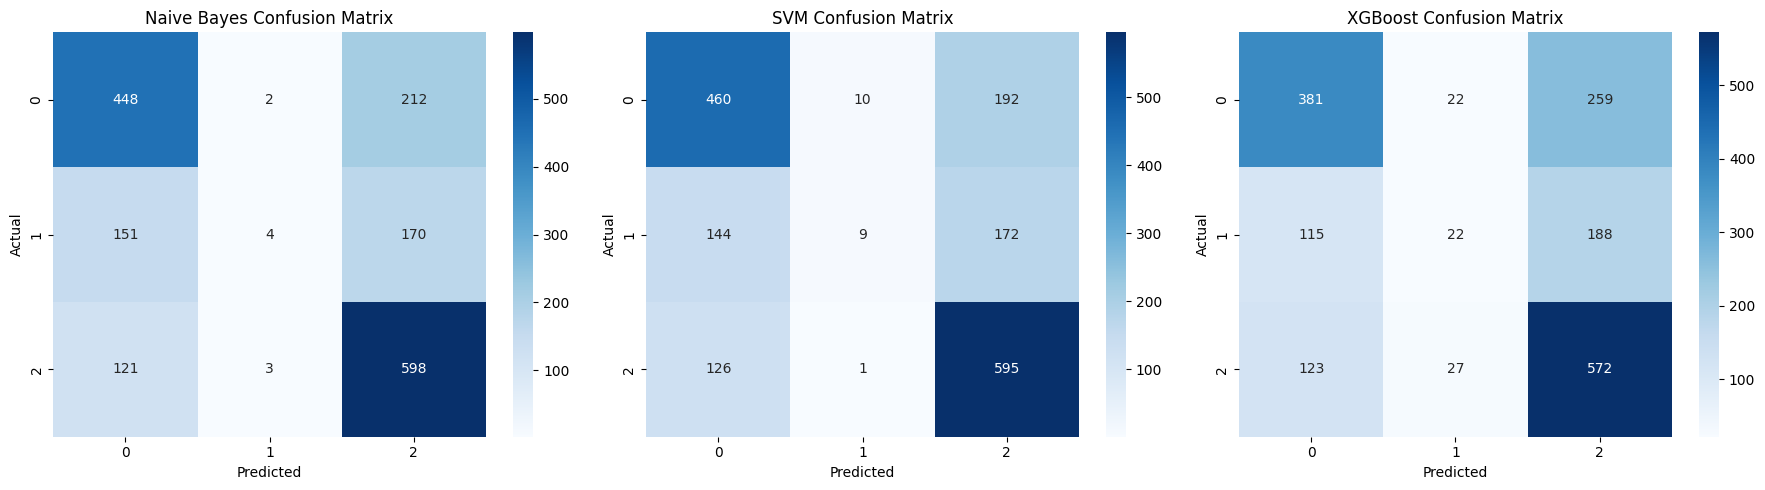

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


models = {
    "Naive Bayes": y_pred_nb,
    "SVM": svm_pred,
    "XGBoost": y_pred_xgb
}


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred_model) in zip(axes, models.items()):
    cm = confusion_matrix(y_val, y_pred_model)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


The results of evaluation show that SVM performed best with 0.6226 of accuracy and closely related to this is Naive Bayes with 0.6144 and XGBoost with 0.5705. Precision, recall, and F1-score SVM again is a little better than the others with fewer bias in its predictions of the three sentiment classes. The confusion matrices support an assumption that the Neutral class is the most challenging to predict, and the Positive and Negative classes are more reliable to be predicted in all models.

On the whole, classical machine learning models that used TF-IDF features representation and post-processing procedures like text cleaning, stopword elimination, and lemmatization gave fairly good performance. Hyperparameter optimization also enhanced the SVM and Naive Bayes performance. Although the XGBoost was not as good, it still learned valuable patterns using the data. In the future, it would be possible to improve with word embeddings or the use of pretrained transformer models (BERT/RoBERTa) to better capture semantic context, which could be used in bettering classification, particularly the challenging classes such as Neutral.

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of the question is to practice different machine learning algorithms for **text classification** as well as the performance evaluation. In addition, you are requried to conduct **10 fold cross validation** (https://scikit-learn.org/stable/modules/cross_validation.html) in the training.



The dataset can be download from canvas. The dataset contains two files train data and test data for sentiment analysis in IMDB review, it has two categories: 1 represents positive and 0 represents negative. You need to split the training data into training and validate data (80% for training and 20% for validation, https://towardsdatascience.com/train-test-split-and-cross-validation-in-python-80b61beca4b6) and perform 10 fold cross validation while training the classifier. The final trained model was final evaluated on the test data.



1.   **Perform EDA on test and tran dataset**

2.   **Algorithms (Minimum 4):**

*   SVM
*   KNN
*   Decision tree
*   Random Forest
*   XGBoost
*   Word2Vec
*   BERT

3. **Evaluation measurement:**

*   Accuracy
*   Recall
*   Precison
*   F-1 score


In [71]:
!pip install wordcloud
!pip install emoji

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path


train_path = "/content/stsa-train.txt"
test_path  = "/content/stsa-test.txt"


def load_sst_style(path):
    texts = []
    labels = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split(" ", 1)
            if len(parts) == 1:

                labels.append(int(parts[0]))
                texts.append("")
            else:
                labels.append(int(parts[0]))
                texts.append(parts[1])
    return pd.DataFrame({"label": labels, "text": texts})

train_df = load_sst_style(train_path)
test_df  = load_sst_style(test_path)

print("TRAIN: rows =", train_df.shape[0], "columns =", train_df.shape[1])
print(train_df.head(6).to_string(index=False))
print("\nTEST: rows =", test_df.shape[0], "columns =", test_df.shape[1])
print(test_df.head(6).to_string(index=False))


print("\nTraining label counts are :")
print(train_df['label'].value_counts(normalize=False))
print("\nTest label counts:")
print(test_df['label'].value_counts(normalize=False))


TRAIN: rows = 6920 columns = 2
 label                                                                                                                                                                                                                              text
     1                                                                                                                           a stirring , funny and finally transporting re-imagining of beauty and the beast and 1930s horror films
     0                                                                                                                                                    apparently reassembled from the cutting-room floor of any given daytime soap .
     0 they presume their audience wo n't sit still for a sociology lesson , however entertainingly presented , so they trot out the conventional science-fiction elements of bug-eyed monsters and futuristic women in skimpy clothes .
     1                               

Train — character length (describe):
count    6920.000000
mean      103.757081
std        51.632333
min         5.000000
25%        64.000000
50%        99.000000
75%       138.250000
max       283.000000
Name: char_len, dtype: float64

Train — word count (describe):
count    6920.000000
mean       19.299855
std         9.318495
min         2.000000
25%        12.000000
50%        19.000000
75%        25.000000
max        52.000000
Name: word_count, dtype: float64

Missing / empty text in train: 0
Missing / empty text in test: 0


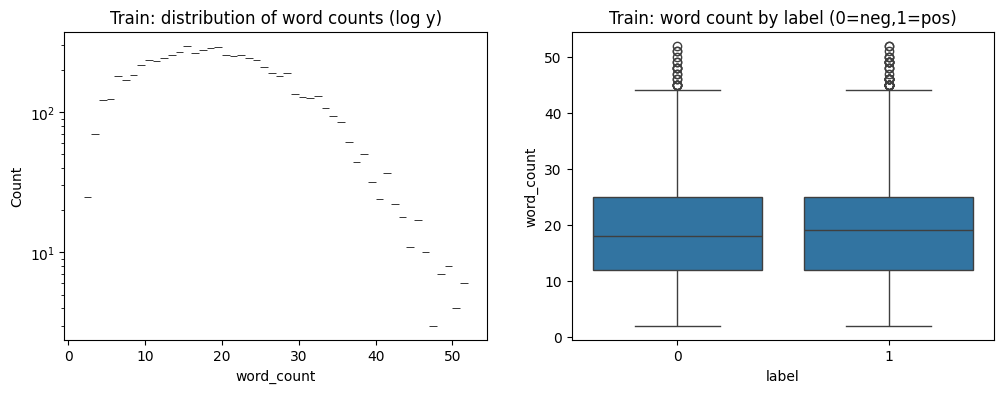

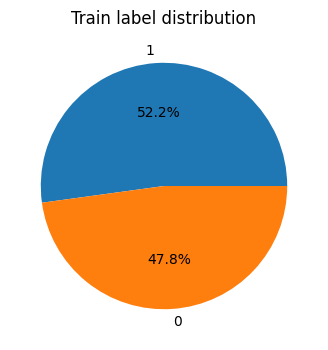

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

def add_text_stats(df):
    df = df.copy()
    df['char_len'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)
    df['has_text'] = df['text'].str.strip().astype(bool)
    return df

train_stats = add_text_stats(train_df)
test_stats  = add_text_stats(test_df)


print("Train — character length (describe):")
print(train_stats['char_len'].describe())
print("\nTrain — word count (describe):")
print(train_stats['word_count'].describe())
print("\nMissing / empty text in train:", (~train_stats['has_text']).sum())
print("Missing / empty text in test:", (~test_stats['has_text']).sum())


plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(train_stats['word_count'], bins=50, log_scale=(False, True))
plt.title("Train: distribution of word counts (log y)")

plt.subplot(1,2,2)
sns.boxplot(x='label', y='word_count', data=train_stats)
plt.title("Train: word count by label (0=neg,1=pos)")
plt.show()


plt.figure(figsize=(6,4))
train_stats['label'].value_counts().plot.pie(autopct="%1.1f%%", ylabel="")
plt.title("Train label distribution")
plt.show()


In [73]:

import html
import string
import re

def clean_text(s, remove_punct=True):
    if not isinstance(s, str):
        return ""
    s = html.unescape(s)
    s = s.lower()


    s = re.sub(r'-lrb-|-rrb-|-lsb-|-rsb-', ' ', s)


    s = re.sub(r'http\S+|www\.\S+', ' ', s)


    if remove_punct:
        s = re.sub(r'[' + re.escape(string.punctuation) + r']+', ' ', s)


    s = re.sub(r'\s+', ' ', s).strip()

    return s


sample = train_df['text'].sample(5, random_state=42).reset_index(drop=True)
for i, t in enumerate(sample):
    print(f"--- BEFORE {i+1} ---\n{t}\n")
    print(f"--- AFTER {i+1} ---\n{clean_text(t)}\n")


--- BEFORE 1 ---
... overly melodramatic ...

--- AFTER 1 ---
overly melodramatic

--- BEFORE 2 ---
-lrb- westbrook -rrb- makes a wonderful subject for the camera .

--- AFTER 2 ---
westbrook makes a wonderful subject for the camera

--- BEFORE 3 ---
mama africa pretty much delivers on that promise .

--- AFTER 3 ---
mama africa pretty much delivers on that promise

--- BEFORE 4 ---
sad nonsense , this .

--- AFTER 4 ---
sad nonsense this

--- BEFORE 5 ---
easily the most thoughtful fictional examination of the root causes of anti-semitism ever seen on screen .

--- AFTER 5 ---
easily the most thoughtful fictional examination of the root causes of anti semitism ever seen on screen



Top 20 Unigrams (Overall)are:
[('film', np.int64(959)), ('movie', np.int64(840)), ('like', np.int64(423)), ('story', np.int64(291)), ('just', np.int64(245)), ('does', np.int64(243)), ('good', np.int64(240)), ('comedy', np.int64(226)), ('time', np.int64(205)), ('characters', np.int64(199)), ('director', np.int64(192)), ('funny', np.int64(188)), ('little', np.int64(177)), ('way', np.int64(168)), ('make', np.int64(158)), ('life', np.int64(155)), ('bad', np.int64(155)), ('work', np.int64(154)), ('makes', np.int64(149)), ('love', np.int64(147))]

Top 20 Bigrams (Overall) are:
[('romantic comedy', np.int64(39)), ('writer director', np.int64(35)), ('ve seen', np.int64(32)), ('feels like', np.int64(30)), ('plays like', np.int64(26)), ('coming age', np.int64(24)), ('soap opera', np.int64(22)), ('old fashioned', np.int64(22)), ('special effects', np.int64(21)), ('love story', np.int64(21)), ('sci fi', np.int64(20)), ('year old', np.int64(20)), ('feel like', np.int64(19)), ('big screen', np.int64

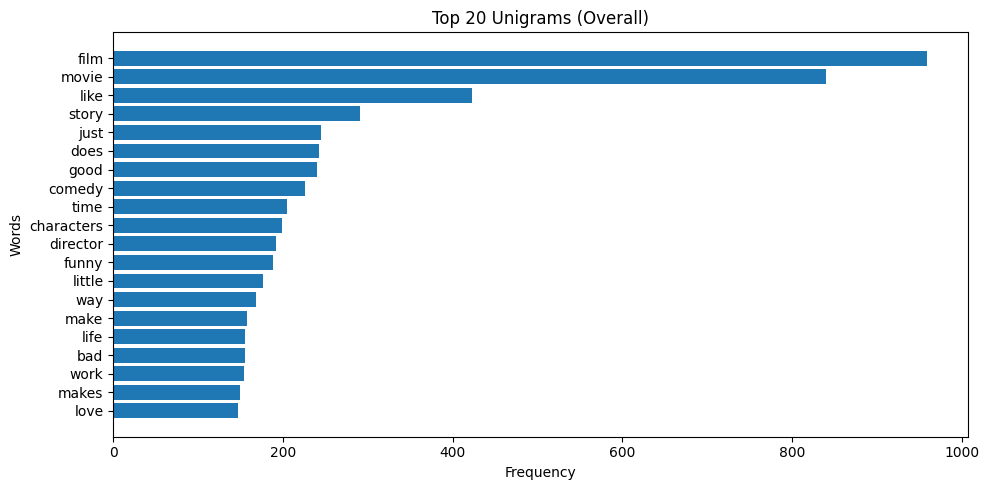

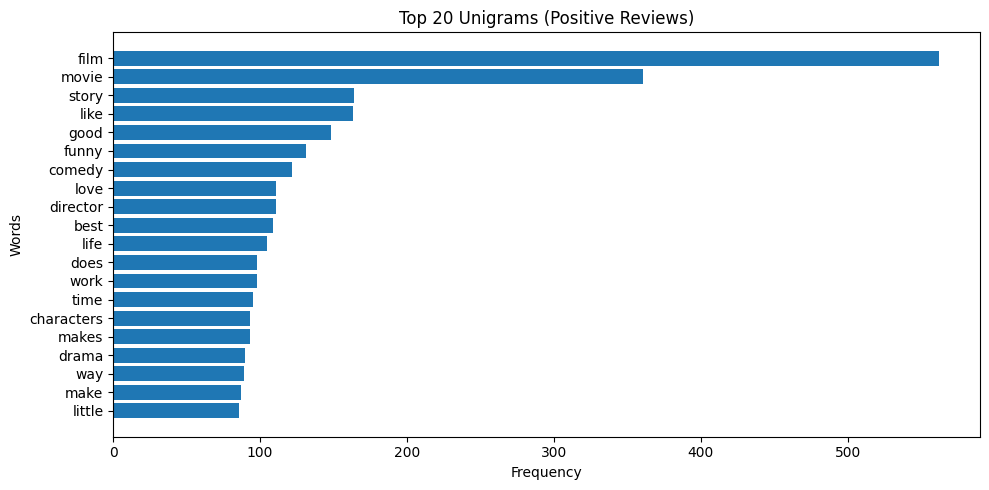

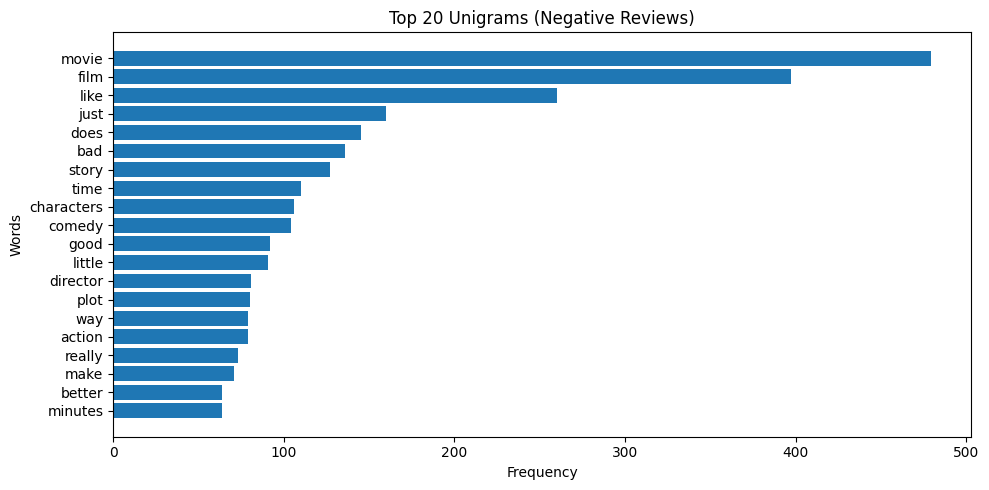

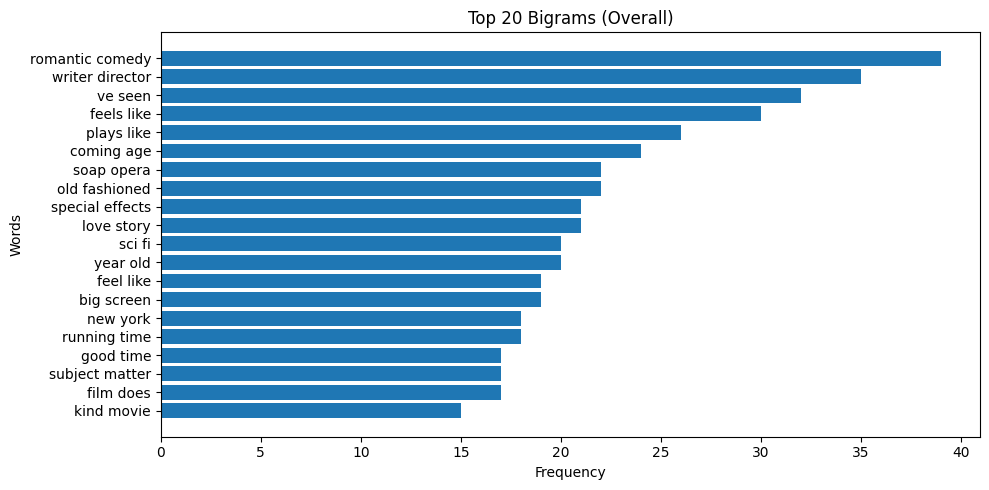

In [74]:

from sklearn.feature_extraction.text import CountVectorizer
import numpy as np


train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

def top_ngrams(corpus, n=20, ngram_range=(1,1)):
    vec = CountVectorizer(ngram_range=ngram_range,
                          stop_words="english",
                          min_df=2)
    X = vec.fit_transform(corpus)
    word_counts = np.array(X.sum(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())

    top_idx = word_counts.argsort()[::-1][:n]
    return list(zip(vocab[top_idx], word_counts[top_idx]))

print("Top 20 Unigrams (Overall)are:")
print(top_ngrams(train_df['clean_text'], n=20, ngram_range=(1,1)))

print("\nTop 20 Bigrams (Overall) are:")
print(top_ngrams(train_df['clean_text'], n=20, ngram_range=(2,2)))


positive_texts = train_df[train_df['label'] == 1]['clean_text']
negative_texts = train_df[train_df['label'] == 0]['clean_text']

print("\nTop 20 Unigrams (Positive reviews):")
print(top_ngrams(positive_texts, n=20))

print("\nTop 20 Unigrams (Negative reviews):")
print(top_ngrams(negative_texts, n=20))



import matplotlib.pyplot as plt

def plot_top_words(title, data):
    """
    data = list of (word, count)
    """
    words = [w for w, c in data]
    counts = [c for w, c in data]

    plt.figure(figsize=(10,5))
    plt.barh(words[::-1], counts[::-1])
    plt.title(title)
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.tight_layout()
    plt.show()


top_uni_overall = top_ngrams(train_df['clean_text'], n=20, ngram_range=(1,1))
plot_top_words("Top 20 Unigrams (Overall)", top_uni_overall)


top_uni_pos = top_ngrams(positive_texts, n=20, ngram_range=(1,1))
plot_top_words("Top 20 Unigrams (Positive Reviews)", top_uni_pos)

top_uni_neg = top_ngrams(negative_texts, n=20, ngram_range=(1,1))
plot_top_words("Top 20 Unigrams (Negative Reviews)", top_uni_neg)


top_bi_overall = top_ngrams(train_df['clean_text'], n=20, ngram_range=(2,2))
plot_top_words("Top 20 Bigrams (Overall)", top_bi_overall)



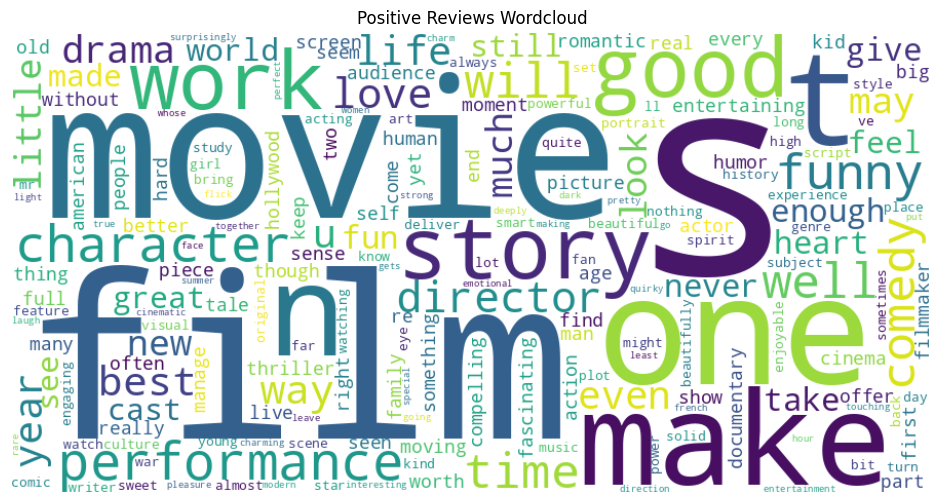

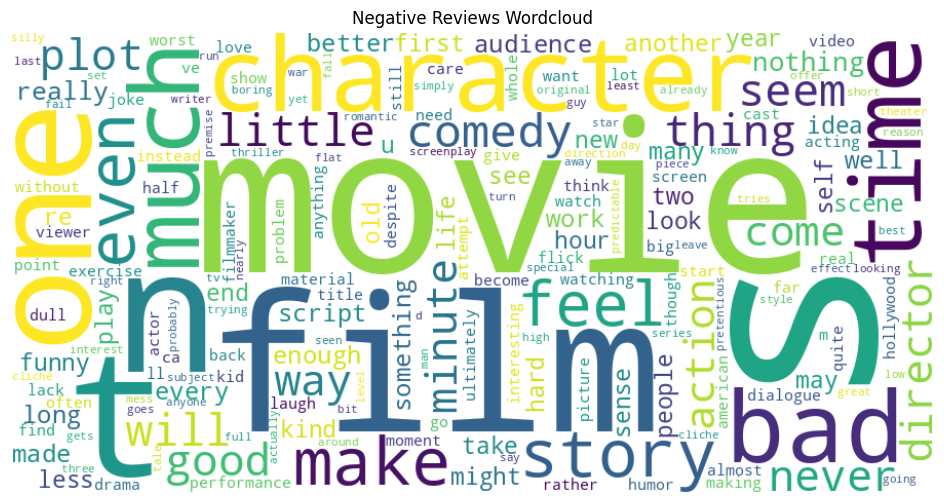

Cleaned files saved in /content/


In [75]:

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def show_wordcloud(texts, title):
    text = " ".join(texts)
    wc = WordCloud(width=900, height=450,
                   background_color="white",
                   collocations=False).generate(text)

    plt.figure(figsize=(12,6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

show_wordcloud(positive_texts, "Positive Reviews Wordcloud")
show_wordcloud(negative_texts, "Negative Reviews Wordcloud")


train_df.to_csv("/content/train_cleaned.csv", index=False)
test_df.to_csv("/content/test_cleaned.csv", index=False)

print("Cleaned files saved in /content/")


In [76]:


from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer


X = train_df['clean_text']
y = train_df['label']


X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples are:", len(X_train))
print("Validation samples are:", len(X_val))


tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)


X_train_tfidf = tfidf.fit_transform(X_train)


X_val_tfidf  = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(test_df['clean_text'])

print("TF-IDF Training shape is:", X_train_tfidf.shape)
print("TF-IDF Validation shape is:", X_val_tfidf.shape)
print("TF-IDF Test shape is:", X_test_tfidf.shape)


Training samples are: 5536
Validation samples are: 1384
TF-IDF Training shape is: (5536, 10000)
TF-IDF Validation shape is: (1384, 10000)
TF-IDF Test shape is: (1821, 10000)


In [77]:
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import numpy as np

models = {
    "SVM (LinearSVC)": LinearSVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

cv_results = {}
val_results = {}


print("10-Fold Cross Validation Results\n")

for name, model in models.items():
    print(f"Training {name} ...")

    scores = cross_val_score(model, X_train_tfidf, y_train, cv=10, scoring='accuracy')

    cv_results[name] = scores
    print(f"{name} - Mean CV Accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})\n")


print("\n Validation Set Performance are:\n")

for name, model in models.items():

    model.fit(X_train_tfidf, y_train)


    y_pred = model.predict(X_val_tfidf)


    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    val_results[name] = (acc, prec, rec, f1)

    print(f"{name}:")
    print(f" Accuracy:  {acc:.4f}")
    print(f" Precision: {prec:.4f}")
    print(f" Recall:    {rec:.4f}")
    print(f" F1-score:  {f1:.4f}\n")


10-Fold Cross Validation Results

Training SVM (LinearSVC) ...
SVM (LinearSVC) - Mean CV Accuracy: 0.7632 (+/- 0.0200)

Training KNN ...
KNN - Mean CV Accuracy: 0.5105 (+/- 0.0113)

Training Decision Tree ...
Decision Tree - Mean CV Accuracy: 0.6458 (+/- 0.0249)

Training Random Forest ...
Random Forest - Mean CV Accuracy: 0.7240 (+/- 0.0181)


 Validation Set Performance are:

SVM (LinearSVC):
 Accuracy:  0.7579
 Precision: 0.7626
 Recall:    0.7784
 F1-score:  0.7704

KNN:
 Accuracy:  0.5116
 Precision: 0.5504
 Recall:    0.3476
 F1-score:  0.4261

Decision Tree:
 Accuracy:  0.6301
 Precision: 0.6558
 Recall:    0.6122
 F1-score:  0.6332

Random Forest:
 Accuracy:  0.6994
 Precision: 0.7149
 Recall:    0.7050
 F1-score:  0.7099



In [78]:

import xgboost as xgb
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)


xgb_cv_scores = cross_val_score(xgb_model, X_train_tfidf, y_train, cv=10, scoring='accuracy')
print("=== XGBoost 10-Fold CV Results ===")
print(f"Mean CV Accuracy: {xgb_cv_scores.mean():.4f} (+/- {xgb_cv_scores.std():.4f})\n")


xgb_model.fit(X_train_tfidf, y_train)
y_val_pred = xgb_model.predict(X_val_tfidf)

xgb_acc  = accuracy_score(y_val, y_val_pred)
xgb_prec = precision_score(y_val, y_val_pred)
xgb_rec  = recall_score(y_val, y_val_pred)
xgb_f1   = f1_score(y_val, y_val_pred)

print("=== XGBoost Validation Set Performance ===")
print(f"Accuracy :  {xgb_acc:.4f}")
print(f"Precision:  {xgb_prec:.4f}")
print(f"Recall   :  {xgb_rec:.4f}")
print(f"F1-score :  {xgb_f1:.4f}")


=== XGBoost 10-Fold CV Results ===
Mean CV Accuracy: 0.6727 (+/- 0.0177)

=== XGBoost Validation Set Performance ===
Accuracy :  0.6546
Precision:  0.6377
Recall   :  0.7825
F1-score :  0.7027


In [79]:


from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


best_model = LinearSVC()
best_model.fit(X_train_tfidf, y_train)


y_test_pred = best_model.predict(X_test_tfidf)

test_acc  = accuracy_score(test_df['label'], y_test_pred)
test_prec = precision_score(test_df['label'], y_test_pred)
test_rec  = recall_score(test_df['label'], y_test_pred)
test_f1   = f1_score(test_df['label'], y_test_pred)


print("Final Test Set Performance (SVM)")
print(f"Accuracy :  {test_acc:.4f}")
print(f"Precision:  {test_prec:.4f}")
print(f"Recall   :  {test_rec:.4f}")
print(f"F1-score :  {test_f1:.4f}")


Final Test Set Performance (SVM)
Accuracy :  0.7803
Precision:  0.7682
Recall   :  0.8020
F1-score :  0.7847


Predictions saved as 'svm_test_predictions.csv'
                                                text  label  predicted_label
0     no movement , no yuks , not much of anything .      0                0
1  a gob of drivel so sickly sweet , even the eag...      0                0
2  gangs of new york is an unapologetic mess , wh...      0                0
3  we never really feel involved with the story ,...      0                0
4            this is one of polanski 's best films .      1                1


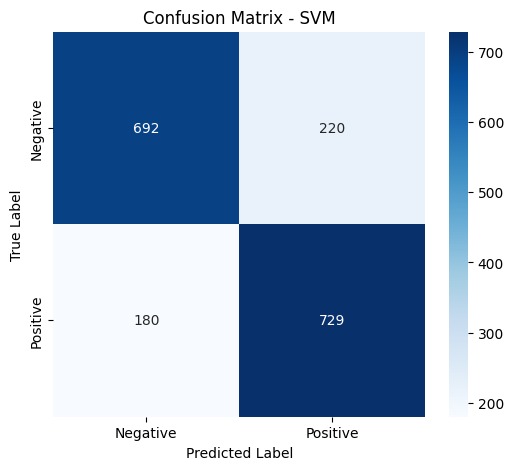

/tmp/ipython-input-513160686.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correct_counts.index, y=correct_counts.values, palette=['red', 'green'])


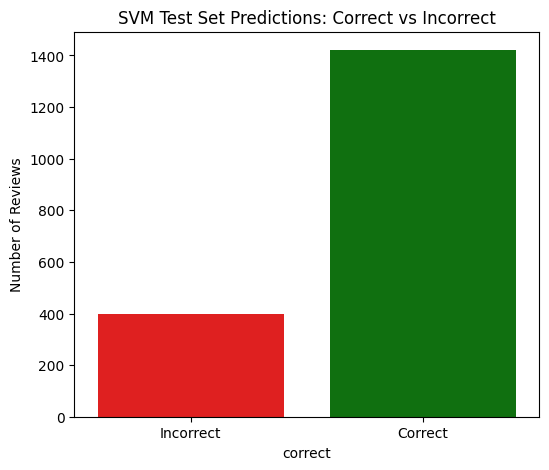

<Figure size 640x480 with 0 Axes>

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

test_df['correct'] = test_df['label'] == test_df['predicted_label']
correct_counts = test_df['correct'].value_counts()


test_df[['text', 'label', 'predicted_label']].to_csv('svm_test_predictions.csv', index=False)
print("Predictions saved as 'svm_test_predictions.csv'")

print(test_df[['text', 'label', 'predicted_label']].head())


cm = confusion_matrix(test_df['label'], test_df['predicted_label'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative','Positive'], yticklabels=['Negative','Positive'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - SVM')
plt.show()


plt.figure(figsize=(6,5))
sns.barplot(x=correct_counts.index, y=correct_counts.values, palette=['red', 'green'])
plt.xticks([0,1], ['Incorrect', 'Correct'])
plt.ylabel('Number of Reviews')
plt.title('SVM Test Set Predictions: Correct vs Incorrect')
plt.show()
plt.savefig('svm_correct_vs_incorrect.png', dpi=300)


## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of the question is to practice different machine learning algorithms for **text clustering**.

Please downlad the dataset by using the following link.  https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones
(You can also use different text data which you want)


1.   Perform EDA on selected dataset

2.   **Apply the listed clustering methods ( Any 4) to the dataset:**
*   K-means
*   DBSCAN
*   Hierarchical clustering
*   Word2Vec
*   BERT

3. **Visualize the clusters**

You can refer to of the codes from  the follwing link below.
https://www.kaggle.com/karthik3890/text-clustering

In [86]:
import pandas as pd
import numpy as np

file_path = "/content/Amazon_Unlocked_Mobile.csv"  # <-- replace with your actual path
df = pd.read_csv(file_path)

print("Shape of the dataset is:", df.shape)
print("\nColumns in the dataset are:", df.columns)
df.head()


Shape of the dataset is: (413840, 6)

Columns in the dataset are: Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes'],
      dtype='object')


,Product Name,Brand Name,Price,Rating,Reviews,Review Votes
0,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,I feel so LUCKY to have found this used (phone...,1.0
1,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,"nice phone, nice up grade from my pantach revu...",0.0
2,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,5,Very pleased,0.0
3,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,It works good but it goes slow sometimes but i...,0.0
4,"""CLEAR CLEAN ESN"" Sprint EPIC 4G Galaxy SPH-D7...",Samsung,199.99,4,Great phone to replace my lost phone. The only...,0.0


In [87]:

print("\nData types of columns are:\n", df.dtypes)
print("\nMissing values in each column are:\n", df.isnull().sum())



Data types of columns are:
 Product Name     object
Brand Name       object
Price           float64
Rating            int64
Reviews          object
Review Votes    float64
dtype: object

Missing values in each column are:
 Product Name        0
Brand Name      65171
Price            5933
Rating              0
Reviews            70
Review Votes    12296
dtype: int64


In [88]:
print("\nSummary statistics for numeric columns:\n", df.describe())


text_column = 'Reviews'


df['review_length'] = df[text_column].astype(str).apply(len)
df['word_count'] = df[text_column].astype(str).apply(lambda x: len(x.split()))

print("\nText statistics:")
print(df[['review_length', 'word_count']].describe())


df[text_column].head()



Summary statistics for numeric columns:
                Price         Rating   Review Votes
count  407907.000000  413840.000000  401544.000000
mean      226.867155       3.819578       1.507237
std       273.006259       1.548216       9.163853
min         1.730000       1.000000       0.000000
25%        79.990000       3.000000       0.000000
50%       144.710000       5.000000       0.000000
75%       269.990000       5.000000       1.000000
max      2598.000000       5.000000     645.000000

Text statistics:
       review_length     word_count
count  413840.000000  413840.000000
mean      216.674555      40.486222
std       463.572761      85.230227
min         1.000000       1.000000
25%        28.000000       5.000000
50%        93.000000      18.000000
75%       223.000000      42.000000
max     29419.000000    5313.000000


,Reviews
0,I feel so LUCKY to have found this used (phone...
1,"nice phone, nice up grade from my pantach revu..."
2,Very pleased
3,It works good but it goes slow sometimes but i...
4,Great phone to replace my lost phone. The only...


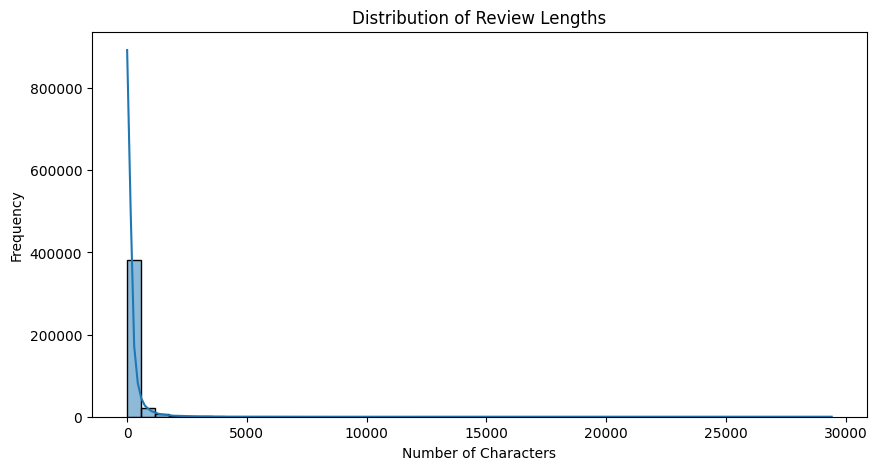

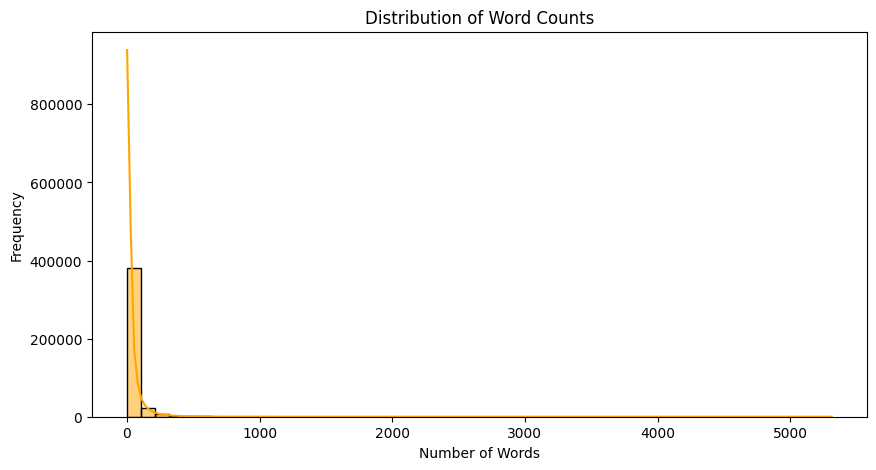

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=50, kde=True)
plt.title('Distribution of Review Lengths')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.show()


plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True, color='orange')
plt.title('Distribution of Word Counts')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()


In [90]:

import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_review'] = df[text_column].apply(clean_text)
df['cleaned_review'].head()


,cleaned_review
0,i feel so lucky to have found this used phone ...
1,nice phone nice up grade from my pantach revue...
2,very pleased
3,it works good but it goes slow sometimes but i...
4,great phone to replace my lost phone the only ...


In [91]:
from sklearn.feature_extraction.text import TfidfVectorizer


tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df['cleaned_review'])


In [92]:
from sklearn.cluster import KMeans


num_clusters = 5
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_tfidf)


terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(num_clusters):
    top_words = [terms[ind] for ind in order_centroids[i, :10]]
    print(f"Cluster {i}: {', '.join(top_words)}")


Cluster 0: great, phone, works, product, price, condition, fast, buy, good, thanks
Cluster 1: love, perfect, phone, great, new, works, good, fast, just, excellent
Cluster 2: good, phone, product, price, works, far, thanks, quality, really, excellent
Cluster 3: phone, excellent, good, great, like, works, nice, product, excelente, just
Cluster 4: ok, phone, thanks, good, price, product, far, works, expected, todo


In [93]:
print("Table of first 20 reviews with K-Means clusters")
df_kmeans_table = df_subset[['cleaned_review', 'kmeans_cluster']].reset_index(drop=True)
df_kmeans_table.head(20)


Table of first 20 reviews with K-Means clusters


,cleaned_review,kmeans_cluster
0,defective phone works only for two days phone ...,3
1,cool,3
2,beautiful and excellent quality,3
3,gave stars because it did not come with a char...,3
4,high resolution camera so you can zoom in afte...,3
5,excelente,3
6,audio port does not work brand new phone then ...,3
7,worked fine functional like every other bb not...,3
8,excellent phone exceeded my expectations,3
9,i bought this phone and it worked great the en...,3


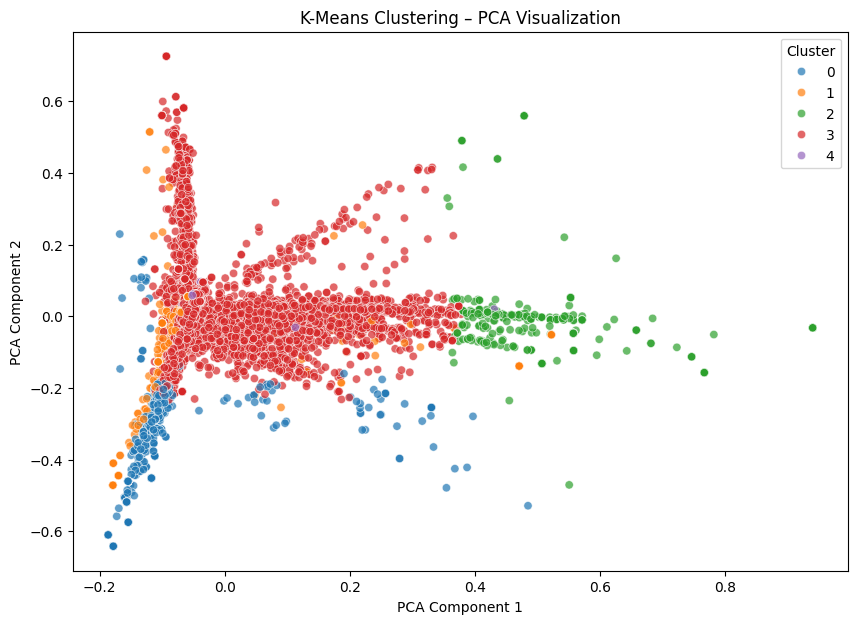

In [94]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


subset_size = 20000
df_subset = df.sample(n=subset_size, random_state=42)
X_subset = X_tfidf[df_subset.index]


pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_subset.toarray())


df_subset['pca_1'] = X_pca[:, 0]
df_subset['pca_2'] = X_pca[:, 1]


plt.figure(figsize=(10,7))
sns.scatterplot(
    x='pca_1', y='pca_2',
    hue='kmeans_cluster',
    data=df_subset,
    palette='tab10',
    alpha=0.7
)
plt.title('K-Means Clustering – PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [95]:
from sklearn.decomposition import TruncatedSVD

subset_size = 20000
df_subset = df.sample(n=subset_size, random_state=42)
X_subset = X_tfidf[df_subset.index]

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_subset)


In [96]:
from sklearn.cluster import DBSCAN
import numpy as np


dbscan = DBSCAN(eps=0.5, min_samples=10, metric='cosine')
dbscan_labels = dbscan.fit_predict(X_reduced)


df_subset['dbscan_cluster'] = dbscan_labels


print(np.unique(dbscan_labels, return_counts=True))


(array([-1,  0]), array([  219, 19781]))


In [97]:
df_subset[['cleaned_review', 'dbscan_cluster']].head(10)
df_subset['dbscan_cluster'].value_counts()


,count
dbscan_cluster,
0,19781
-1,219


In [98]:
print("Table of first 20 reviews with DBSCAN clusters")
df_dbscan_table = df_subset[['cleaned_review', 'dbscan_cluster']].reset_index(drop=True)
df_dbscan_table.head(20)


Table of first 20 reviews with DBSCAN clusters


,cleaned_review,dbscan_cluster
0,defective phone works only for two days phone ...,0
1,cool,0
2,beautiful and excellent quality,0
3,gave stars because it did not come with a char...,0
4,high resolution camera so you can zoom in afte...,0
5,excelente,0
6,audio port does not work brand new phone then ...,0
7,worked fine functional like every other bb not...,0
8,excellent phone exceeded my expectations,0
9,i bought this phone and it worked great the en...,0


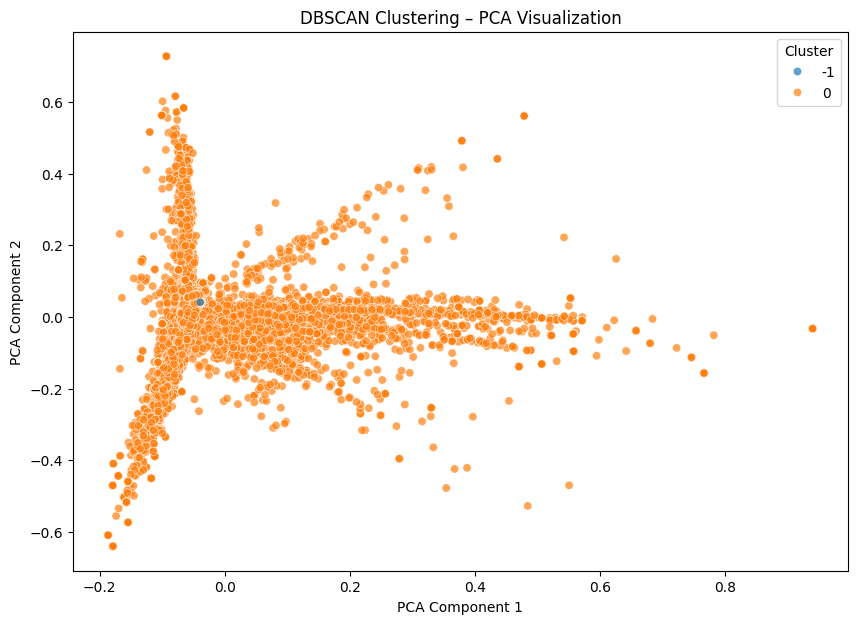

In [99]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

df_subset['pca_1'] = X_pca[:, 0]
df_subset['pca_2'] = X_pca[:, 1]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='pca_1', y='pca_2',
    hue='dbscan_cluster',
    data=df_subset,
    palette='tab10',
    alpha=0.7
)
plt.title('DBSCAN Clustering – PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [100]:
from sklearn.decomposition import TruncatedSVD

subset_size = 5000
df_subset = df.sample(n=subset_size, random_state=42)
X_subset = X_tfidf[df_subset.index]

svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced = svd.fit_transform(X_subset)


In [101]:
from sklearn.cluster import AgglomerativeClustering
num_clusters = 5
agglo = AgglomerativeClustering(n_clusters=num_clusters, metric='euclidean', linkage='ward')

df_subset['hier_cluster'] = agglo.fit_predict(X_reduced)

df_subset['hier_cluster'].value_counts()


,count
hier_cluster,
0,4575
4,153
2,95
1,94
3,83


In [102]:
print("Table of first 20 reviews with hierarchical clusters")
df_hier_table = df_subset[['cleaned_review', 'hier_cluster']].reset_index(drop=True)
df_hier_table.head(20)


Table of first 20 reviews with hierarchical clusters


,cleaned_review,hier_cluster
0,defective phone works only for two days phone ...,0
1,cool,0
2,beautiful and excellent quality,0
3,gave stars because it did not come with a char...,0
4,high resolution camera so you can zoom in afte...,0
5,excelente,2
6,audio port does not work brand new phone then ...,0
7,worked fine functional like every other bb not...,0
8,excellent phone exceeded my expectations,0
9,i bought this phone and it worked great the en...,0


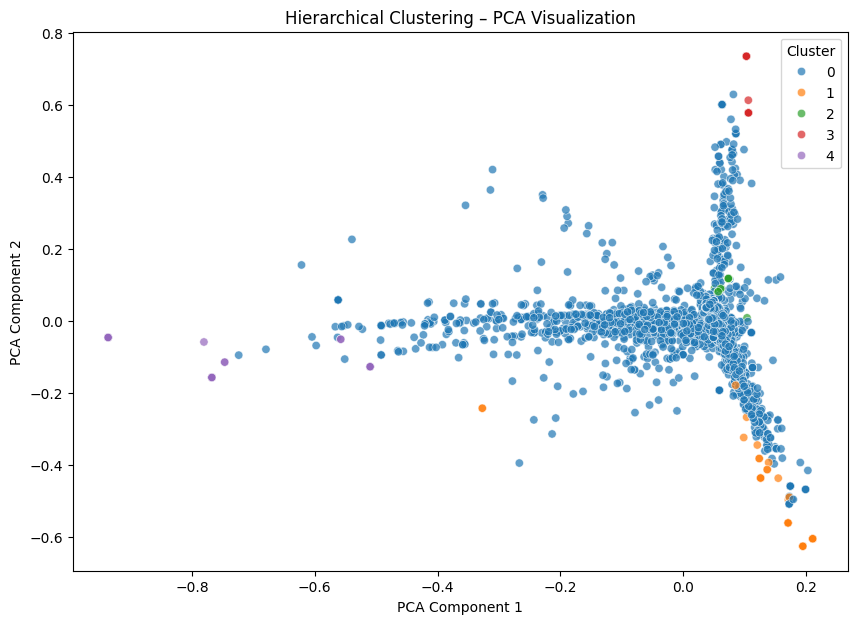

In [103]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_reduced)

df_subset['pca_1'] = X_pca[:, 0]
df_subset['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='pca_1', y='pca_2',
    hue='hier_cluster',
    data=df_subset,
    palette='tab10',
    alpha=0.7
)
plt.title('Hierarchical Clustering – PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [104]:
!pip install gensim


In [105]:
subset_size = 20000
df_subset = df.sample(n=subset_size, random_state=42)


In [106]:
tokenized_reviews = [review.split() for review in df_subset['cleaned_review']]


In [107]:
from gensim.models import Word2Vec
w2v_model = Word2Vec(
    sentences=tokenized_reviews,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    seed=42
)


In [108]:
import numpy as np

def review_vector(words, model):
    vecs = [model.wv[word] for word in words if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

review_vectors = np.array([review_vector(r, w2v_model) for r in tokenized_reviews])


In [109]:
from sklearn.cluster import KMeans

num_clusters = 5
kmeans_w2v = KMeans(n_clusters=num_clusters, random_state=42)
df_subset['w2v_cluster'] = kmeans_w2v.fit_predict(review_vectors)

df_subset['w2v_cluster'].value_counts()


,count
w2v_cluster,
0,13481
2,4137
4,1167
1,712
3,503


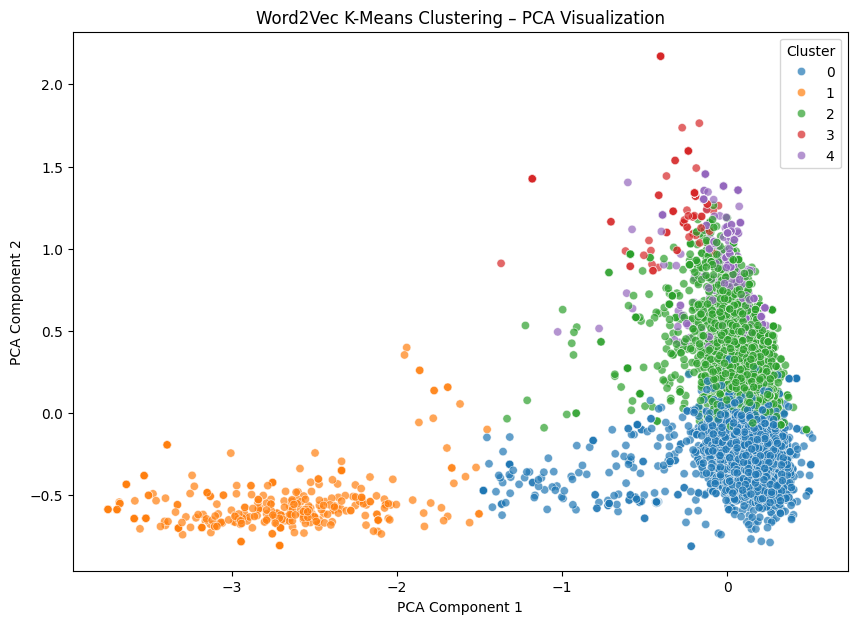

In [110]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(review_vectors)

df_subset['pca_1'] = X_pca[:, 0]
df_subset['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='pca_1', y='pca_2',
    hue='w2v_cluster',
    data=df_subset,
    palette='tab10',
    alpha=0.7
)
plt.title('Word2Vec K-Means Clustering – PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [111]:
df_w2v_table = df_subset[['cleaned_review', 'w2v_cluster']].head(20)
df_w2v_table


,cleaned_review,w2v_cluster
54870,defective phone works only for two days phone ...,0
188521,cool,2
137548,beautiful and excellent quality,2
24906,gave stars because it did not come with a char...,0
131601,high resolution camera so you can zoom in afte...,0
200532,excelente,1
343472,audio port does not work brand new phone then ...,0
90499,worked fine functional like every other bb not...,0
160693,excellent phone exceeded my expectations,2
119347,i bought this phone and it worked great the en...,0


In [112]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns


In [113]:
subset_size = 5000
df_subset = df.sample(n=subset_size, random_state=42)
reviews_subset = df_subset['cleaned_review'].tolist()


In [114]:
model = SentenceTransformer('all-MiniLM-L6-v2')

bert_vectors = model.encode(reviews_subset, show_progress_bar=True)


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [115]:
num_clusters = 5
kmeans_bert = KMeans(n_clusters=num_clusters, random_state=42)
df_subset['bert_cluster'] = kmeans_bert.fit_predict(bert_vectors)

df_subset['bert_cluster'].value_counts()


,count
bert_cluster,
4,1734
1,1486
2,1208
0,341
3,231


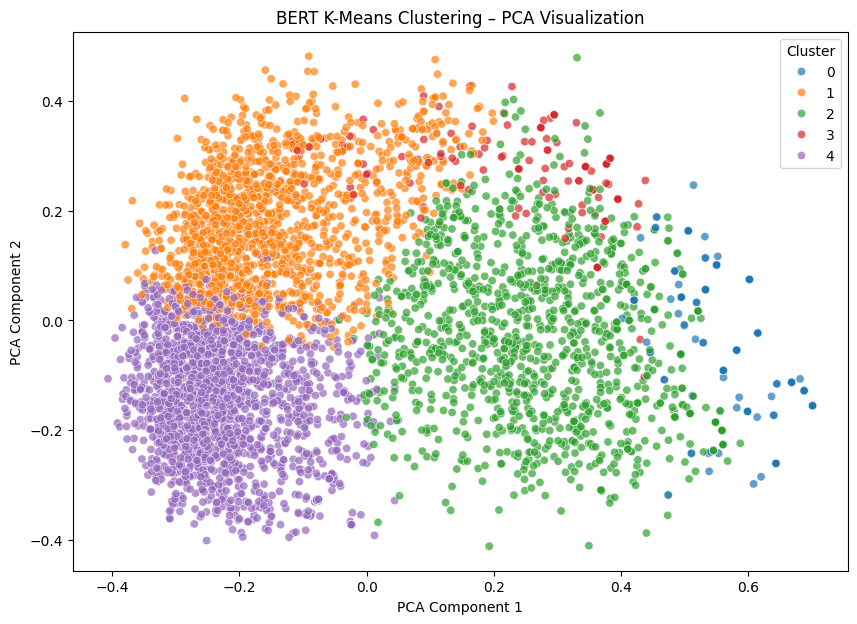

In [116]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(bert_vectors)

df_subset['pca_1'] = X_pca[:, 0]
df_subset['pca_2'] = X_pca[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='pca_1', y='pca_2',
    hue='bert_cluster',
    data=df_subset,
    palette='tab10',
    alpha=0.7
)
plt.title('BERT K-Means Clustering – PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()


In [117]:
df_bert_table = df_subset[['cleaned_review', 'bert_cluster']].head(20)
df_bert_table


,cleaned_review,bert_cluster
54870,defective phone works only for two days phone ...,1
188521,cool,0
137548,beautiful and excellent quality,2
24906,gave stars because it did not come with a char...,4
131601,high resolution camera so you can zoom in afte...,4
200532,excelente,3
343472,audio port does not work brand new phone then ...,1
90499,worked fine functional like every other bb not...,2
160693,excellent phone exceeded my expectations,4
119347,i bought this phone and it worked great the en...,1


**In one paragraph, please compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec, and BERT.**

**Write your response here:**

The performance of the K-means, DBSCAN, Hierarchical, Word2Vec, and BERT clustering indicate different trends and performance. TF-IDF K-means divided reviews majorly on the frequency of words and formed such clusters as great, phone, works etc, which had obvious separation, but occasionally similar meanings reviews were classified as different clusters. DBSCAN concentrated heavily on the dense clusters and most of the reviews were contained in cluster 0 and few of the reviews were designated as outliers (-1), which are unique or sparse reviews. The hierarchical clustering method needed dimensionality reduction to be efficient and was able to record a relationship between similar reviews creating a nested hierarchy. Word2Vec clustering divided reviews into meaningful clusters as per their semantic similarity as opposed to specific words, thus creating meaningful clusters like bundling positive reviews or complaints. BERT embeddings were able to capture context and sentiment, creating the most semantically coherent clusters, and all the reviews, though phrased differently, can have a same meaning. Altogether, semantic embedding techniques (Word2Vec and BERT) were more detailed, context-specific clusters, whereas TF-IDF-based techniques were less complicated, quicker and applicable to high-level topic segregation.

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**



I filled the form